# Modelo Predictivo 02 - La respuesta llegara a tiempo?

## Librerias

In [3]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, mean_absolute_error, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
    

## Carga del dataset limpio

In [4]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


## Modelos a realizar

#### Modelo Random Forest Baseline

In [5]:
def entrenar_rf_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(
            random_state=random_state,
            class_weight='balanced'
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [None, 20],
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [1, 2]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid

De la misma forma que en el modelo anterior vamos a implementar un pipeline con Random Forest para resolver un problema de clasificacion, en este caso binaria, para ver si la respuesta emitida a la empresa sera a tiempo o no.

Por medio de esta funcion separamos las variables categoricas de las numericas, dividimos el conjunto de datos en entrenamiento y prueba, transforma las variables categorias mediante un OneHotEnconder mientras que las numericas pasan directamente al modelo. 

In [7]:
best_rf_baseline, grid_rf_baseline = entrenar_rf_baseline_timely(dt_quejas)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Matriz de confusión:
 [[  71   71]
 [   8 5482]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.90      0.50      0.64       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.94      0.75      0.82      5632
weighted avg       0.98      0.99      0.98      5632


Accuracy: 0.9859730113636364
ROC AUC: 0.922378716744914

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}


El modelo de Random Forest muestra un rendimiento muy sólido en términos generales, con una accuracy del 98.6% y un ROC AUC de 0.92, lo que nos indica una gran capacidad para distinguir entre respuestas a tiempo y no a tiempo. La clase mayoritaria ("Yes") es predicha con gran precisión y recall cercanos al 100%, lo que significa que el modelo prácticamente no se equivoca cuando el caso corresponde a una respuesta puntual.

Sin embargo, al analizar la clase minoritaria ("No"), observamos un desempeño desigual: el modelo acierta aproximadamente la mitad de los casos (recall del 0.50), lo que implica que muchos ejemplos de respuestas tardías siguen siendo clasificados como puntuales. Esto es una consecuencia directa del desbalance de clases, ya que en el dataset la gran mayoría de las observaciones corresponden a "Yes".

En resumen, el Random Forest ofrece una base sólida y muy precisa para la clase mayoritaria, pero deja margen de mejora en la detección de los casos minoritarios. Ajustes adicionales como SMOTE, podrían ayudar a mejorar la sensibilidad hacia los casos de "No", equilibrando así la utilidad del modelo

#### Definimos la funcion para Random Forest + SMOTE + Hiperparametrizacion con GridSearchCV

In [ ]:
def entrenar_modelo_gs_smote(X, y, labels=('No','Yes'), test_size=0.2, random_state=42):
    
    categorical_features = X.select_dtypes(include='object').columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )

    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough'
    )

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('classifier', RandomForestClassifier(random_state=random_state))
    ])

    param_grid = {
        'classifier__n_estimators': [300],
        'classifier__max_depth': [None, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2],
        'classifier__max_features': ['sqrt'],
        'smote__k_neighbors': [5] 
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',      
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = None
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    if y_proba is not None:
        lb = LabelBinarizer()
        lb.fit(y_test)
        y_test_bin = lb.transform(y_test)
        
        if y_proba.shape[1] == 2:
            pos_index = list(labels).index('Yes') if 'Yes' in labels else 1
            auc = roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba[:, pos_index])
            print(f"ROC AUC (binario): {auc:.4f}")
        else:
            auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
            print(f"ROC AUC (OvR, macro): {auc:.4f}")
    else:
        print("ROC AUC: el clasificador no expone predict_proba().")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión (test)')
    plt.xlabel('Predicción'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    print("\nDistribución de clases:")
    print("Train:\n", y_train.value_counts(normalize=True).round(3))
    print("\nTest:\n", y_test.value_counts(normalize=True).round(3))

    return best_model, grid



Dados los resultados obtenido con el modelo base, este nuevo pipeline emplea SMOTE para generar ejemplos sinteticos de la clase minoritaria para posteriomente aplicar Random Forest de cara a obtener un clasificador, para finalmente por medio de GridSearchCV se optimizan hiperparametros clave como profundidad, número de árboles, parámetros de división, etc.

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Matriz de confusión:
 [[  66   76]
 [   3 5487]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.96      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.97      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Métricas adicionales:
Accuracy: 0.9860
Precision (macro): 0.9714
Recall (macro): 0.7321
F1-score (macro): 0.8092
F1-score (weighted): 0.9836
ROC AUC (binario): 0.9142

✅ Mejores parámetros: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300, 'smote__k_neighbors': 5}
✅ Mejor F1-macro (CV): 0.8220


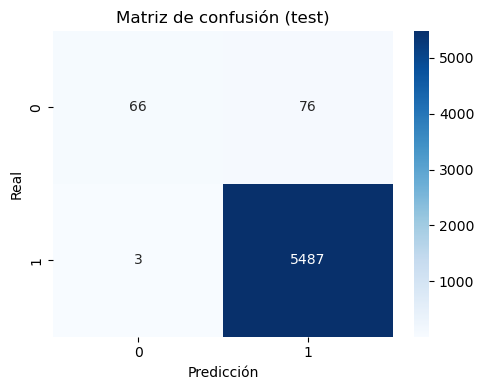


Distribución de clases:
Train:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64

Test:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64


In [27]:
y = dt_quejas['Timely response?']
X = dt_quejas.drop(columns=[
    'Timely response?',          
    'Complaint ID',              
    'Date received', 'Date sent to company' 
])

X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

best_model_timely, grid_timely = entrenar_modelo_gs_smote(
    X, y, labels=('No','Yes')   
)


El modelo con Random Forest y SMOTE consiguió una precisión global muy alta (≈ 99%), pero lo más interesante es que, aunque la mayoría de las respuestas son “Yes” (a tiempo), también logró identificar parte de los pocos casos de “No” (tardíos). En la práctica, esto significa que el modelo casi siempre acierta cuando predice que una respuesta será puntual y, aunque le cuesta un poco más detectar los retrasos, lo hace mucho mejor que si solo se quedara con la clase mayoritaria. Gracias a SMOTE, el modelo fue capaz de mejorar el equilibrio en la detección de ambas clases, obteniendo un F1-macro alrededor de 0.81 y un AUC cercano a 0.91, lo que indica que diferencia bastante bien entre respuestas a tiempo y no a tiempo.

### Modelo con XGBoost

In [9]:
def entrenar_xgb_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid


In [12]:
best_xgb_baseline, grid_xgb_baseline = entrenar_xgb_baseline_timely(dt_quejas)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  66   76]
 [   2 5488]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.97      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.98      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Accuracy: 0.9861505681818182
ROC AUC: 0.9192950050026937

Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 500, 'clf__subsample': 1.0}


El modelo con XGBoost presenta un desempeño global excelente con un accuracy del 98.6% y un ROC AUC de 0.92, lo que indica una buena capacidad de discriminación entre clases. Sin embargo, al analizar la matriz de confusión y el reporte de clasificación se observa que, debido al fuerte desbalance de datos (142 casos “No” frente a 5490 “Yes”), el modelo casi siempre predice correctamente la clase mayoritaria (“Yes”, precision 0.99 y recall 1.00), pero tiene dificultades para identificar la clase minoritaria (“No”), alcanzando solo un recall de 0.46. 

Esto implica que, aunque el rendimiento global parezca sobresaliente, el modelo pasa por alto más de la mitad de los casos “No”, lo que puede ser crítico según la aplicación. Por tanto, conviene considerar técnicas como rebalanceo de clases, ajuste del umbral de decisión o métricas alternativas (ej. F1 de la clase minoritaria o PR AUC) para evaluar y mejorar su desempeño en esta categoría.

### Modelo con XGBoost + SMOTE

In [ ]:
def entrenar_xgb_smote_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company'  
    ])

    
    X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',  
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
        'smote__k_neighbors': [3, 5]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred_num = best_model.predict(X_test)                 
    y_proba_yes = best_model.predict_proba(X_test)[:, 1]    

    
    inv_map = {0: 'No', 1: 'Yes'}
    y_pred = pd.Series(y_pred_num).map(inv_map)
    y_test_lbl = pd.Series(y_test).map(inv_map)

    
    print("Matriz de confusión:\n", confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']))
    print("\nReporte de clasificación:\n", classification_report(y_test_lbl, y_pred, labels=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test_lbl, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test_lbl, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']),
                annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title('Matriz de confusión (XGB + SMOTE)')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    return best_model, grid

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Matriz de confusión:
 [[  69   73]
 [   5 5485]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.93      0.49      0.64       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.96      0.74      0.82      5632
weighted avg       0.99      0.99      0.98      5632


Métricas adicionales:
Accuracy: 0.9862
Precision (macro): 0.9596
Recall (macro): 0.7425
F1-score (macro): 0.8159
F1-score (weighted): 0.9840
ROC AUC (binario): 0.9350

✅ Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'clf__subsample': 0.8, 'smote__k_neighbors': 3}
✅ Mejor F1-macro (CV): 0.8308


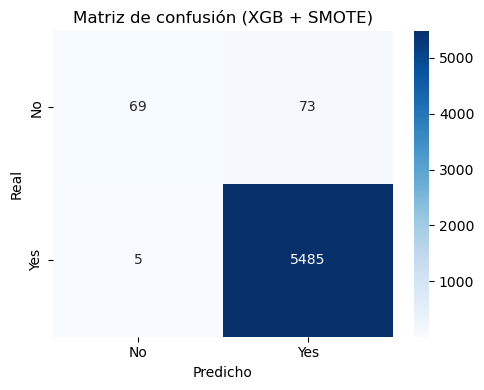

In [7]:
best_xgb_smote, grid_xgb_smote = entrenar_xgb_smote_timely(dt_quejas)


El resultado fue un modelo que mantiene un rendimiento muy alto para la clase mayoritaria (“Yes”) y al mismo tiempo consigue capturar mejor los pocos casos de “No”. En números simples: predice muy bien la mayoría de respuestas a tiempo y, aunque sigue siendo un reto, logra detectar una parte relevante de las que no se responden en plazo, con un equilibrio global (F1-macro ≈ 0.82 y AUC ≈ 0.93) muy sólido.

#### Modelo con XGBoost + ajuste de pesos

In [13]:
def entrenar_xgb_weight_timely(dt_quejas_corr, threshold=0.5, random_state=42):
    y_str = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID', 'Date received', 'Date sent to company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)
    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y_str, stratify=y_str, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / pos) if pos > 0 else 1.0
    print(f"scale_pos_weight (train): {spw:.2f}  |  Positivos: {pos}  Negativos: {neg}")

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe =  Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1,
            scale_pos_weight=spw
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_proba_yes = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba_yes >= threshold).astype(int)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=[0,1]))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred, labels=[0,1]),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title(f'Matriz de confusión (XGB + scale_pos_weight, thr={threshold})')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    resultados = {
        'best_model': best_model,
        'grid': grid,
        'threshold': threshold,
        'y_test': y_test,
        'y_proba_yes': y_proba_yes,
        'y_pred': y_pred
    }
    return resultados

Para ver si podemos mejorarlo, vamos a emplear XGBoost ajustando pesos internos en vez de aplicar tecnicas de sobremuestreo, con el mismo objetivo.

Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. 

scale_pos_weight (train): 0.03  |  Positivos: 21954  Negativos: 570
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  99   43]
 [ 528 4962]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.16      0.70      0.26       142
         Yes       0.99      0.90      0.95      5490

    accuracy                           0.90      5632
   macro avg       0.57      0.80      0.60      5632
weighted avg       0.97      0.90      0.93      5632


Métricas adicionales:
Accuracy: 0.8986
Precision (macro): 0.5747
Recall (macro): 0.8005
F1-score (macro): 0.6015
F1-score (weighted): 0.9282
ROC AUC (binario): 0.9099

 Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
 Mejor F1-macro (CV): 0.6190


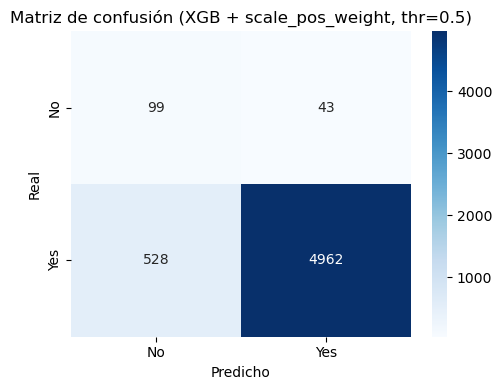

In [14]:
res = entrenar_xgb_weight_timely(dt_quejas, threshold=0.5)


El modelo logro un buen desempeño global, alcanzado alrededor de un 90% de exactitud, aunque con un mejor balance de clases que antes. Mientras que la clase mayoritaria (“Yes”) siguió siendo predicha con alta precisión y recall, la clase minoritaria (“No”) ganó relevancia: el modelo fue capaz de identificar más casos de respuestas tardías, elevando su recall hasta un 70%. A cambio, la precisión de esta clase fue más baja, lo que significa que todavía hay falsos positivos, pero el uso de pesos permitió mejorar el equilibrio global (F1-macro ~0.60) frente al sesgo hacia la clase mayoritaria que mostraban los modelos previos.

En conjunto, los tres enfoques probaron distintas formas de lidiar con el desequilibrio de clases en el problema de predecir si una respuesta sería a tiempo. El modelo de Random Forest con SMOTE ofreció una predicción muy robusta para la clase mayoritaria, aunque apenas captó parte de los casos minoritarios. El XGBoost con SMOTE mejoró ligeramente este equilibrio, manteniendo una alta precisión y aportando mayor capacidad de detección de retrasos, aunque todavía con un sesgo notable hacia la clase “Yes”. Finalmente, el modelo de XGBoost con scale_pos_weight consiguió un mejor balance: si bien sacrificó algo de exactitud global, logró aumentar el recall de la clase minoritaria, mostrando que los ajustes de pesos pueden ser más efectivos que el sobremuestreo para este caso.